# IE 306 - Assignment 2
## Coordinated Traffic Corridor Simulation

Discrete-event simulation of a two-intersection corridor (S -> N main flow,
W -> E cross-traffic) using **SimPy**. The model implements:

* Two-phase fixed-time signal controllers with amber/all-red clearance.
* Optional coordination between intersection A and B via an offset phi.
* Poisson arrivals split into cars (85%), buses (10%, non-preemptive queue
  priority), and emergency vehicles (5%, preempts the signal).
* Downstream blocking on the A -> B link (point queue, finite jam-density
  capacity, occupancy-dependent travel time).
* Emergency preemption: 4 s all-red clearance, >=10 s minimum NS green,
  resume the interrupted phase with its remaining time.
* Three scenarios: uncoordinated, coordinated, coordinated + emergencies.
* 20 replications, 15 min warm-up, 2 h run length, 95% confidence intervals.


## 1. Imports and global configuration

In [1]:
import heapq
import itertools
import math
from dataclasses import dataclass
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
import simpy
import matplotlib.pyplot as plt
from scipy import stats as scistats

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
np.set_printoptions(suppress=True, precision=3)


## 2. Parameters

All numerical parameters are collected in a single dictionary that is passed
around to every SimPy process.  The `offset` and `emergencies_enabled` fields
are the two knobs that differentiate the three experimental scenarios.


In [2]:
DEFAULT_PARAMS = dict(
    # --- corridor geometry ---
    L=300.0,                   # link length (m)
    vf=15.0,                   # free-flow speed (m/s)
    Nmax=40,                   # link storage capacity (veh) = k_j * L
    # --- signal timing ---
    cycle=90,                  # cycle length (s)
    g_NS=45,                   # NS green (s)
    amber=4,                   # amber / all-red clearance (s)
    g_WE=37,                   # WE green (s)
    offset=0,                  # coordination offset phi (s)
    # --- demand ---
    lam_S=900.0 / 3600.0,      # S-entry arrival rate (veh/s)
    lam_WE=400.0 / 3600.0,     # W/E arrival rate per intersection (veh/s)
    p_car=0.85,
    p_bus=0.10,
    p_emerg=0.05,
    turn_A_E=0.30,             # proportion turning E at A
    turn_B_E=0.20,             # proportion turning E at B
    # --- service ---
    mu_service=2.0,            # mean Exp service time (s)
    # --- preemption ---
    emerg_min_green=10,        # minimum NS green after preemption (s)
    emerg_clearance=4,         # all-red before preemption NS green (s)
    emergencies_enabled=False, # scenario switch
    # --- simulation control ---
    warmup=900,                # 15 min warm-up
    sim_time=7200,             # 2 h total run length
    replications=20,
)

# Vehicle priority ordering (lower value = served first).
PRIORITY_EMERGENCY = 0
PRIORITY_BUS = 1
PRIORITY_CAR = 2

PRIORITY_MAP = {
    "emergency": PRIORITY_EMERGENCY,
    "bus": PRIORITY_BUS,
    "car": PRIORITY_CAR,
}


## 3. Vehicle record

A plain dataclass keeps per-vehicle state.  `total_delay` accumulates queueing
time across the intersections the vehicle visits (free-flow link travel and
service time are **not** counted as delay).


In [3]:
@dataclass
class Vehicle:
    vid: int
    vtype: str                     # 'car' | 'bus' | 'emergency'
    origin: str                    # 'S' (south entry) or 'W_A' / 'W_B'
    arrival_time: float
    total_delay: float = 0.0       # queueing delay across intersections
    service_time_total: float = 0.0
    exited_via: Optional[str] = None
    enqueue_time: float = 0.0
    service_done_event: object = None


## 4. Signal controller

The controller is a single SimPy process that cycles through
`NS -> AMBER -> WE -> AMBER`.  The four phases are stored as a list; we keep
a `remaining` counter so preemption can interrupt the current phase and later
resume it with the correct leftover time.

**Design choices.**

* Each approach process waits on `phase_change_event` to learn about phase
  transitions.  We re-create the event after every notify so waiters can
  re-arm fresh `yield`s.
* `request_preempt()` is a no-op when the signal is already green for N/S or
  a preemption sequence is already in progress, which avoids double-triggering.
* The coordination offset is handled by computing the initial
  `(idx, remaining)` such that at `env.now == 0` the signal is "in the
  middle" of its cycle at position `(-offset) mod C`.  For `offset = 20 s`,
  intersection B starts with 16 s of W/E green remaining, then the first
  amber, then its first N/S green at `t = 20 s` - which is exactly the
  free-flow travel time along the link.


In [4]:
class SignalController:
    PHASE_NS = "NS"
    PHASE_WE = "WE"
    PHASE_AMBER = "AMBER"

    def __init__(self, env, name, offset, params):
        self.env = env
        self.name = name
        self.offset = offset
        self.params = params
        self.phase = self.PHASE_AMBER
        self.phase_change_event = env.event()
        self.preempting = False
        self.last_emerg_done_time: Optional[float] = None
        self.preemption_count = 0
        self.recovery_times: List[float] = []
        self.proc = env.process(self._run())

    # ----- public API -----
    def is_green(self, direction: str) -> bool:
        return self.phase == direction

    def request_preempt(self) -> None:
        if self.phase == self.PHASE_NS or self.preempting:
            return
        self.proc.interrupt("preempt")

    # ----- internals -----
    def _set_phase(self, p: str) -> None:
        self.phase = p
        old = self.phase_change_event
        self.phase_change_event = self.env.event()
        old.succeed()

    def _initial_state(self):
        gNS = self.params["g_NS"]
        amb = self.params["amber"]
        gWE = self.params["g_WE"]
        C = self.params["cycle"]
        boundaries = [
            (self.PHASE_NS, 0, gNS),
            (self.PHASE_AMBER, gNS, gNS + amb),
            (self.PHASE_WE, gNS + amb, gNS + amb + gWE),
            (self.PHASE_AMBER, gNS + amb + gWE, C),
        ]
        pos = (-self.offset) % C
        for idx, (_ph, s, e) in enumerate(boundaries):
            if s <= pos < e:
                return idx, e - pos
        return 0, gNS

    def _run(self):
        gNS = self.params["g_NS"]
        amb = self.params["amber"]
        gWE = self.params["g_WE"]
        phases = [
            (self.PHASE_NS, gNS),
            (self.PHASE_AMBER, amb),
            (self.PHASE_WE, gWE),
            (self.PHASE_AMBER, amb),
        ]
        idx, remaining = self._initial_state()
        while True:
            ph, _ = phases[idx]
            self._set_phase(ph)
            start = self.env.now
            try:
                yield self.env.timeout(remaining)
                idx = (idx + 1) % 4
                remaining = phases[idx][1]
            except simpy.Interrupt:
                elapsed = self.env.now - start
                saved_idx = idx
                saved_remaining = max(0.0, remaining - elapsed)
                self.preempting = True
                self.preemption_count += 1
                # 4 s all-red clearance
                self._set_phase(self.PHASE_AMBER)
                yield self.env.timeout(self.params["emerg_clearance"])
                # minimum NS green
                self._set_phase(self.PHASE_NS)
                yield self.env.timeout(self.params["emerg_min_green"])
                # recovery time = from emergency service end to cycle resume
                if self.last_emerg_done_time is not None:
                    rt = self.env.now - self.last_emerg_done_time
                    self.recovery_times.append(max(0.0, rt))
                    self.last_emerg_done_time = None
                self.preempting = False
                # Resume interrupted phase with its leftover time.
                idx = saved_idx
                remaining = saved_remaining
                if remaining <= 1e-9:
                    idx = (idx + 1) % 4
                    remaining = phases[idx][1]


## 5. Link A -> B (point queue with finite storage)

The link has a jam-density-derived capacity of 40 vehicles.  Travel time is
computed at the moment of entry from the current occupancy `n`:

$$t_\text{travel}(n) = \frac{L}{v_f}\cdot\frac{1}{1 - n/N_\max}.$$

Vehicles entering a full link are blocked at the upstream intersection A
(downstream blocking), except emergency vehicles that always proceed.


In [5]:
class Link:
    def __init__(self, env, capacity, L, vf):
        self.env = env
        self.capacity = capacity
        self.L = L
        self.vf = vf
        self.occupancy = 0
        self.space_event = env.event()
        self.samples: List[Tuple[float, int]] = [(0.0, 0)]

    def is_full(self) -> bool:
        return self.occupancy >= self.capacity

    def enter(self) -> None:
        self.occupancy += 1
        self.samples.append((self.env.now, self.occupancy))

    def leave(self) -> None:
        self.occupancy -= 1
        self.samples.append((self.env.now, self.occupancy))
        if not self.space_event.triggered:
            self.space_event.succeed()
            self.space_event = self.env.event()

    def travel_time(self) -> float:
        # Cap at capacity-1 to avoid division by zero in pathological states.
        n_eff = min(self.occupancy, self.capacity - 1)
        return (self.L / self.vf) * (1.0 / (1.0 - n_eff / self.capacity))


## 6. Intersection approach (priority queue + single server)

Each approach owns one SimPy process that:

1. Waits for the signal to show green for its direction.
2. Peeks the highest-priority vehicle in its queue.  Buses jump ahead of
   cars non-preemptively; emergency vehicles have the highest priority slot.
3. If the vehicle is at A's N/S approach and the link A->B is full (and the
   vehicle is not an emergency), it **blocks** the approach until space
   opens, a new arrival appears, or the phase ends - recording the blocking
   event for the current cycle.
4. Otherwise it pops the vehicle, samples an `Exp(mu_service)` service
   time, yields for that duration, and releases the vehicle via its
   `service_done_event`.  Service started before amber continues normally;
   amber only prevents *new* services from starting.

The queue is a heap of `(priority, counter, vehicle)` so that FIFO order is
preserved within a priority class.


In [6]:
class IntersectionApproach:
    def __init__(self, env, name, direction, signal, params,
                 rng_service, link=None, is_A_NS=False):
        self.env = env
        self.name = name
        self.direction = direction        # 'NS' or 'WE'
        self.signal = signal
        self.params = params
        self.rng_service = rng_service
        self.link = link
        self.is_A_NS = is_A_NS
        self.queue: List[Tuple[int, int, Vehicle]] = []
        self._counter = itertools.count()
        self.new_vehicle_event = env.event()
        self.samples: List[Tuple[float, int]] = [(0.0, 0)]
        self.max_queue = 0
        self.blocked_any_in_current_cycle = False
        self.blocked_cycle_flags: List[bool] = []
        self.proc = env.process(self._serve_loop())

    def enqueue(self, vehicle: Vehicle) -> None:
        priority = PRIORITY_MAP[vehicle.vtype]
        vehicle.enqueue_time = self.env.now
        heapq.heappush(self.queue, (priority, next(self._counter), vehicle))
        self._record_q()
        if not self.new_vehicle_event.triggered:
            self.new_vehicle_event.succeed()

    def _record_q(self) -> None:
        qsize = len(self.queue)
        self.samples.append((self.env.now, qsize))
        if qsize > self.max_queue:
            self.max_queue = qsize

    def _serve_loop(self):
        while True:
            if self.signal.is_green(self.direction):
                if self.queue:
                    _, _, top = self.queue[0]
                    # Downstream blocking check (A-NS only, non-emergency).
                    if (self.is_A_NS and top.vtype != "emergency"
                            and self.link.is_full()):
                        self.blocked_any_in_current_cycle = True
                        nv = self.new_vehicle_event
                        pc = self.signal.phase_change_event
                        sp = self.link.space_event
                        yield self.env.any_of([nv, pc, sp])
                        if nv.triggered:
                            self.new_vehicle_event = self.env.event()
                        continue
                    heapq.heappop(self.queue)
                    self._record_q()
                    wait = self.env.now - top.enqueue_time
                    top.total_delay += wait
                    service = self.rng_service.exponential(self.params["mu_service"])
                    yield self.env.timeout(service)
                    top.service_time_total += service
                    if top.vtype == "emergency":
                        # Record the emergency-clear moment for recovery time.
                        self.signal.last_emerg_done_time = self.env.now
                    top.service_done_event.succeed()
                else:
                    nv = self.new_vehicle_event
                    pc = self.signal.phase_change_event
                    yield self.env.any_of([nv, pc])
                    if nv.triggered:
                        self.new_vehicle_event = self.env.event()
            else:
                yield self.signal.phase_change_event


def blocking_cycle_watcher(env, signal: SignalController,
                           approach: IntersectionApproach):
    """Finalise the cycle's downstream-blocking flag each time A-NS goes green."""
    while True:
        yield signal.phase_change_event
        if signal.phase == SignalController.PHASE_NS:
            approach.blocked_cycle_flags.append(
                approach.blocked_any_in_current_cycle
            )
            approach.blocked_any_in_current_cycle = False


## 7. Arrival streams and vehicle trajectories

* `arrival_S_process` - Poisson arrivals at the south entry of A, classified
  into car / bus / emergency using an independent RNG.
* `arrival_WE_process` - independent Poisson stream for each intersection's
  W/E approach (all regular cars).
* `vehicle_SN_trajectory` - S -> A -> (maybe turn east) -> link -> B -> exit
  north or turn east, with emergency preemption requested on arrival at
  each intersection.
* `vehicle_WE_trajectory` - W -> intersection -> E (single stop).


In [7]:
def classify_arrival(r: float, params: dict) -> str:
    p_car = params["p_car"]
    p_bus = params["p_bus"]
    if r < p_car:
        return "car"
    if r < p_car + p_bus:
        return "bus"
    return "emergency" if params["emergencies_enabled"] else "car"


def arrival_S_process(env, int_A, int_B, link, stats, params, rngs):
    vid_counter = itertools.count()
    while True:
        yield env.timeout(rngs["arrival_S"].exponential(1.0 / params["lam_S"]))
        r = rngs["classify"].random()
        vtype = classify_arrival(r, params)
        v = Vehicle(vid=next(vid_counter), vtype=vtype, origin="S",
                    arrival_time=env.now)
        env.process(vehicle_SN_trajectory(env, v, int_A, int_B, link,
                                          stats, params, rngs))


def arrival_WE_process(env, intersection, stats, params, rng, label):
    vid_counter = itertools.count()
    while True:
        yield env.timeout(rng.exponential(1.0 / params["lam_WE"]))
        v = Vehicle(vid=next(vid_counter), vtype="car", origin=label,
                    arrival_time=env.now)
        env.process(vehicle_WE_trajectory(env, v, intersection, stats, params))


def vehicle_SN_trajectory(env, v, int_A, int_B, link, stats, params, rngs):
    # ---- arrive at A ----
    app_A = int_A["ns_approach"]
    if v.vtype == "emergency":
        int_A["signal"].request_preempt()
    v.service_done_event = env.event()
    app_A.enqueue(v)
    yield v.service_done_event

    # ---- turn at A? ----
    if rngs["turn"].random() < params["turn_A_E"]:
        v.exited_via = "turn_A_E"
        stats.record(v)
        return

    # ---- traverse link ----
    link.enter()
    travel = link.travel_time()
    yield env.timeout(travel)
    link.leave()

    # ---- arrive at B ----
    app_B = int_B["ns_approach"]
    if v.vtype == "emergency":
        int_B["signal"].request_preempt()
    v.service_done_event = env.event()
    app_B.enqueue(v)
    yield v.service_done_event

    # ---- turn at B? ----
    if rngs["turn"].random() < params["turn_B_E"]:
        v.exited_via = "turn_B_E"
    else:
        v.exited_via = "exit_N"
    stats.record(v)


def vehicle_WE_trajectory(env, v, intersection, stats, params):
    app = intersection["we_approach"]
    v.service_done_event = env.event()
    app.enqueue(v)
    yield v.service_done_event
    v.exited_via = "W_to_E"
    stats.record(v)


## 8. Stats collector and KPI computation

`Stats` drops any vehicle whose arrival time is within the warm-up period.
`compute_kpis` turns the per-replication raw data into the KPIs required by
the assignment:

1. Average delay per vehicle (separately for S->N and W/E streams)
2. Max / average queue length at each approach
3. Throughput (veh/h exiting northbound at B)
4. Average link occupancy
5. Downstream-blocking frequency
6. Preemption count + average recovery time (scenario 3)


In [8]:
class Stats:
    def __init__(self, warmup: float):
        self.warmup = warmup
        self.vehicles: List[Vehicle] = []

    def record(self, v: Vehicle) -> None:
        if v.arrival_time >= self.warmup:
            self.vehicles.append(v)


def time_weighted_mean(samples, t_start, t_end):
    """Integrate a step-function sample list over [t_start, t_end]."""
    if not samples:
        return 0.0
    prev_t = t_start
    prev_v = 0
    acc = 0.0
    duration = 0.0
    for t, v in samples:
        if t < t_start:
            prev_v = v
            continue
        if t >= t_end:
            dt = t_end - prev_t
            if dt > 0:
                acc += prev_v * dt
                duration += dt
            return acc / duration if duration > 0 else 0.0
        dt = t - prev_t
        if dt > 0:
            acc += prev_v * dt
            duration += dt
        prev_t = t
        prev_v = v
    dt = t_end - prev_t
    if dt > 0:
        acc += prev_v * dt
        duration += dt
    return acc / duration if duration > 0 else 0.0


def post_warmup_max(samples, warmup):
    m = 0
    for t, v in samples:
        if t >= warmup and v > m:
            m = v
    return m


def compute_kpis(stats, link, sig_A, sig_B, approaches, params):
    warmup = params["warmup"]
    end = params["sim_time"]
    duration = end - warmup

    SN = [v for v in stats.vehicles if v.origin == "S"]
    WE = [v for v in stats.vehicles if v.origin in ("W_A", "W_B")]

    def mean(xs):
        return float(np.mean(xs)) if xs else 0.0

    avg_delay_SN = mean([v.total_delay for v in SN])
    avg_delay_WE = mean([v.total_delay for v in WE])

    exit_N = sum(1 for v in SN if v.exited_via == "exit_N")
    throughput_NB = exit_N / duration * 3600.0

    avg_link_occ = time_weighted_mean(link.samples, warmup, end)

    q_stats = {}
    for key, app in approaches.items():
        q_stats[f"avg_q_{key}"] = time_weighted_mean(app.samples, warmup, end)
        q_stats[f"max_q_{key}"] = post_warmup_max(app.samples, warmup)

    flags = approaches["A_NS"].blocked_cycle_flags
    blocking_freq = float(np.mean(flags)) if flags else 0.0

    all_recoveries = sig_A.recovery_times + sig_B.recovery_times
    avg_recovery = mean(all_recoveries)

    return {
        "avg_delay_SN": avg_delay_SN,
        "avg_delay_WE": avg_delay_WE,
        "throughput_NB": throughput_NB,
        "avg_link_occ": avg_link_occ,
        "blocking_freq": blocking_freq,
        "preempt_count": sig_A.preemption_count + sig_B.preemption_count,
        "avg_recovery_time": avg_recovery,
        **q_stats,
        "n_SN": len(SN),
        "n_WE": len(WE),
    }


## 9. Single simulation runner

One call to `run_simulation(seed, params)` executes a full 2-hour replication
and returns its KPI dictionary.  Each random source gets its own RNG seeded
through a `SeedSequence`, so replications are reproducible and independent
streams are fully decoupled.


In [9]:
RNG_STREAMS = [
    "arrival_S", "arrival_WE_A", "arrival_WE_B",
    "classify", "turn",
    "service_A_NS", "service_A_WE", "service_B_NS", "service_B_WE",
    "misc",
]


def _make_rngs(seed):
    ss = np.random.SeedSequence(seed)
    children = ss.spawn(len(RNG_STREAMS))
    return {name: np.random.default_rng(children[i])
            for i, name in enumerate(RNG_STREAMS)}


def run_simulation(seed, params):
    env = simpy.Environment()
    rngs = _make_rngs(seed)

    sig_A = SignalController(env, "A", offset=0, params=params)
    sig_B = SignalController(env, "B", offset=params["offset"], params=params)

    link = Link(env, capacity=params["Nmax"], L=params["L"], vf=params["vf"])

    app_A_NS = IntersectionApproach(env, "A_NS", "NS", sig_A, params,
                                    rngs["service_A_NS"],
                                    link=link, is_A_NS=True)
    app_A_WE = IntersectionApproach(env, "A_WE", "WE", sig_A, params,
                                    rngs["service_A_WE"])
    app_B_NS = IntersectionApproach(env, "B_NS", "NS", sig_B, params,
                                    rngs["service_B_NS"])
    app_B_WE = IntersectionApproach(env, "B_WE", "WE", sig_B, params,
                                    rngs["service_B_WE"])

    int_A = {"signal": sig_A, "ns_approach": app_A_NS, "we_approach": app_A_WE}
    int_B = {"signal": sig_B, "ns_approach": app_B_NS, "we_approach": app_B_WE}

    stats = Stats(warmup=params["warmup"])

    env.process(arrival_S_process(env, int_A, int_B, link, stats, params, rngs))
    env.process(arrival_WE_process(env, int_A, stats, params,
                                   rngs["arrival_WE_A"], "W_A"))
    env.process(arrival_WE_process(env, int_B, stats, params,
                                   rngs["arrival_WE_B"], "W_B"))
    env.process(blocking_cycle_watcher(env, sig_A, app_A_NS))

    env.run(until=params["sim_time"])

    return compute_kpis(
        stats, link, sig_A, sig_B,
        {"A_NS": app_A_NS, "A_WE": app_A_WE,
         "B_NS": app_B_NS, "B_WE": app_B_WE},
        params,
    )


## 10. Sanity check: a single short replication

Before running the full experiment we run one short replication so we can
inspect the KPI dictionary and confirm that the plumbing works end-to-end.


In [10]:
smoke_params = dict(DEFAULT_PARAMS, sim_time=3600, warmup=300,
                    offset=20, emergencies_enabled=True)
smoke_kpis = run_simulation(seed=42, params=smoke_params)
pd.Series(smoke_kpis).to_frame("value")


,value
avg_delay_SN,77.675
avg_delay_WE,21.922
throughput_NB,505.091
avg_link_occ,4.545
blocking_freq,0.000
preempt_count,35.000
avg_recovery_time,7.439
avg_q_A_NS,15.839
max_q_A_NS,48.000
avg_q_A_WE,2.252


## 11. Replication driver and confidence intervals

`run_scenario` executes `n_reps` replications with distinct seeds and returns
a dataframe with one row per replication.  `summarize` turns that into means
and 95% Student-t confidence intervals.


In [11]:
def run_scenario(params, n_reps, base_seed=12345, verbose=False):
    rows = []
    for r in range(n_reps):
        kpis = run_simulation((base_seed, r), params)
        rows.append(kpis)
        if verbose:
            print(f"  rep {r+1:02d}/{n_reps}: "
                  f"delay_SN={kpis['avg_delay_SN']:.1f}s  "
                  f"thr={kpis['throughput_NB']:.0f} veh/h")
    return pd.DataFrame(rows)


def summarize(df):
    out = {}
    for col in df.columns:
        vals = df[col].values
        n = len(vals)
        mean = float(vals.mean())
        if n > 1:
            sem = vals.std(ddof=1) / math.sqrt(n)
            half = scistats.t.ppf(0.975, df=n-1) * sem
        else:
            half = 0.0
        out[col] = {"mean": mean, "ci_half": float(half),
                    "ci_low": mean - float(half),
                    "ci_high": mean + float(half)}
    return pd.DataFrame(out).T


## 12. Scenario 1 - Uncoordinated, no emergencies

Both intersections start their cycles at `t = 0` (offset `phi = 0`).
Emergency vehicles are disabled, so 5% of southbound draws are reclassified
as regular cars.


In [12]:
params_S1 = dict(DEFAULT_PARAMS, offset=0, emergencies_enabled=False)
df_S1 = run_scenario(params_S1, params_S1["replications"],
                     base_seed=1001, verbose=True)
summary_S1 = summarize(df_S1)
summary_S1


  rep 01/20: delay_SN=85.8s  thr=485 veh/h
  rep 02/20: delay_SN=149.3s  thr=493 veh/h
  rep 03/20: delay_SN=98.8s  thr=483 veh/h
  rep 04/20: delay_SN=57.6s  thr=489 veh/h
  rep 05/20: delay_SN=70.3s  thr=499 veh/h
  rep 06/20: delay_SN=71.8s  thr=489 veh/h
  rep 07/20: delay_SN=62.1s  thr=491 veh/h
  rep 08/20: delay_SN=257.0s  thr=477 veh/h


  rep 09/20: delay_SN=71.8s  thr=487 veh/h
  rep 10/20: delay_SN=115.0s  thr=477 veh/h
  rep 11/20: delay_SN=83.5s  thr=499 veh/h
  rep 12/20: delay_SN=61.5s  thr=484 veh/h
  rep 13/20: delay_SN=63.8s  thr=481 veh/h
  rep 14/20: delay_SN=77.0s  thr=484 veh/h
  rep 15/20: delay_SN=135.1s  thr=511 veh/h
  rep 16/20: delay_SN=105.3s  thr=489 veh/h
  rep 17/20: delay_SN=102.3s  thr=509 veh/h


  rep 18/20: delay_SN=82.7s  thr=498 veh/h
  rep 19/20: delay_SN=111.5s  thr=489 veh/h
  rep 20/20: delay_SN=67.0s  thr=506 veh/h


,mean,ci_half,ci_low,ci_high
avg_delay_SN,96.452,21.296,75.156,117.749
avg_delay_WE,21.411,0.324,21.087,21.736
throughput_NB,490.914,4.620,486.294,495.534
avg_link_occ,4.231,0.042,4.190,4.273
blocking_freq,0.000,0.000,0.000,0.000
preempt_count,0.000,0.000,0.000,0.000
avg_recovery_time,0.000,0.000,0.000,0.000
avg_q_A_NS,19.875,5.559,14.315,25.434
max_q_A_NS,53.350,9.348,44.002,62.698
avg_q_A_WE,2.382,0.103,2.278,2.485


## 13. Scenario 2 - Coordinated, no emergencies

Same as Scenario 1 but with `phi = 20 s`, i.e. B's N/S green starts one
free-flow travel time after A's - vehicles leaving A should arrive at B just
as B turns green.


In [13]:
params_S2 = dict(DEFAULT_PARAMS, offset=20, emergencies_enabled=False)
df_S2 = run_scenario(params_S2, params_S2["replications"],
                     base_seed=1001, verbose=True)
summary_S2 = summarize(df_S2)
summary_S2


  rep 01/20: delay_SN=75.7s  thr=488 veh/h
  rep 02/20: delay_SN=139.9s  thr=509 veh/h
  rep 03/20: delay_SN=90.5s  thr=482 veh/h
  rep 04/20: delay_SN=47.5s  thr=491 veh/h
  rep 05/20: delay_SN=61.6s  thr=502 veh/h
  rep 06/20: delay_SN=62.3s  thr=491 veh/h


  rep 07/20: delay_SN=51.1s  thr=485 veh/h
  rep 08/20: delay_SN=248.0s  thr=477 veh/h


  rep 09/20: delay_SN=63.1s  thr=486 veh/h
  rep 10/20: delay_SN=106.2s  thr=474 veh/h
  rep 11/20: delay_SN=74.1s  thr=502 veh/h
  rep 12/20: delay_SN=52.4s  thr=478 veh/h
  rep 13/20: delay_SN=51.7s  thr=484 veh/h
  rep 14/20: delay_SN=67.4s  thr=490 veh/h


  rep 15/20: delay_SN=126.7s  thr=501 veh/h
  rep 16/20: delay_SN=96.3s  thr=498 veh/h
  rep 17/20: delay_SN=92.8s  thr=509 veh/h


  rep 18/20: delay_SN=72.0s  thr=500 veh/h
  rep 19/20: delay_SN=102.7s  thr=489 veh/h
  rep 20/20: delay_SN=57.2s  thr=524 veh/h


,mean,ci_half,ci_low,ci_high
avg_delay_SN,86.955,21.465,65.490,108.419
avg_delay_WE,21.319,0.448,20.871,21.767
throughput_NB,493.000,5.873,487.127,498.873
avg_link_occ,4.226,0.056,4.170,4.282
blocking_freq,0.000,0.000,0.000,0.000
preempt_count,0.000,0.000,0.000,0.000
avg_recovery_time,0.000,0.000,0.000,0.000
avg_q_A_NS,19.875,5.559,14.315,25.434
max_q_A_NS,53.350,9.348,44.002,62.698
avg_q_A_WE,2.382,0.103,2.278,2.485


## 14. Scenario 3 - Coordinated, with emergencies

Emergency vehicles are enabled (5% of southbound arrivals) and the signals
preempt the current phase when they arrive outside N/S green.  The
preemption-related KPIs (`preempt_count`, `avg_recovery_time`) become
meaningful here.


In [14]:
params_S3 = dict(DEFAULT_PARAMS, offset=20, emergencies_enabled=True)
df_S3 = run_scenario(params_S3, params_S3["replications"],
                     base_seed=1001, verbose=True)
summary_S3 = summarize(df_S3)
summary_S3


  rep 01/20: delay_SN=54.7s  thr=488 veh/h
  rep 02/20: delay_SN=86.0s  thr=507 veh/h
  rep 03/20: delay_SN=60.3s  thr=490 veh/h


  rep 04/20: delay_SN=43.2s  thr=490 veh/h
  rep 05/20: delay_SN=41.1s  thr=504 veh/h


  rep 06/20: delay_SN=46.6s  thr=493 veh/h
  rep 07/20: delay_SN=40.5s  thr=491 veh/h
  rep 08/20: delay_SN=143.1s  thr=510 veh/h


  rep 09/20: delay_SN=56.0s  thr=486 veh/h
  rep 10/20: delay_SN=62.2s  thr=471 veh/h
  rep 11/20: delay_SN=48.7s  thr=498 veh/h


  rep 12/20: delay_SN=39.9s  thr=479 veh/h
  rep 13/20: delay_SN=49.6s  thr=489 veh/h
  rep 14/20: delay_SN=55.7s  thr=495 veh/h


  rep 15/20: delay_SN=71.7s  thr=507 veh/h
  rep 16/20: delay_SN=63.9s  thr=505 veh/h
  rep 17/20: delay_SN=69.2s  thr=517 veh/h


  rep 18/20: delay_SN=45.0s  thr=499 veh/h
  rep 19/20: delay_SN=46.4s  thr=495 veh/h


  rep 20/20: delay_SN=48.5s  thr=516 veh/h


,mean,ci_half,ci_low,ci_high
avg_delay_SN,58.616,10.862,47.754,69.479
avg_delay_WE,22.519,0.578,21.941,23.098
throughput_NB,496.543,5.478,491.065,502.021
avg_link_occ,4.205,0.053,4.152,4.258
blocking_freq,0.000,0.000,0.000,0.000
preempt_count,74.950,4.245,70.705,79.195
avg_recovery_time,8.085,0.462,7.623,8.547
avg_q_A_NS,11.855,2.833,9.022,14.687
max_q_A_NS,39.850,7.276,32.574,47.126
avg_q_A_WE,2.524,0.127,2.397,2.651


## 15. Comparative KPI table

The table below collects the headline KPIs across the three scenarios, each
with its 95% CI half-width.


In [15]:
KPI_ORDER = [
    "avg_delay_SN", "avg_delay_WE",
    "throughput_NB", "avg_link_occ", "blocking_freq",
    "avg_q_A_NS", "max_q_A_NS",
    "avg_q_B_NS", "max_q_B_NS",
    "avg_q_A_WE", "max_q_A_WE",
    "avg_q_B_WE", "max_q_B_WE",
    "preempt_count", "avg_recovery_time",
]


def format_scenario(summary, label):
    col = []
    for k in KPI_ORDER:
        m = summary.loc[k, "mean"]
        h = summary.loc[k, "ci_half"]
        col.append(f"{m:,.3f} +/- {h:,.3f}")
    return pd.Series(col, index=KPI_ORDER, name=label)


comparative = pd.concat([
    format_scenario(summary_S1, "S1 Uncoord"),
    format_scenario(summary_S2, "S2 Coord"),
    format_scenario(summary_S3, "S3 Coord+Emerg"),
], axis=1)
comparative


,S1 Uncoord,S2 Coord,S3 Coord+Emerg
avg_delay_SN,96.452 +/- 21.296,86.955 +/- 21.465,58.616 +/- 10.862
avg_delay_WE,21.411 +/- 0.324,21.319 +/- 0.448,22.519 +/- 0.578
throughput_NB,490.914 +/- 4.620,493.000 +/- 5.873,496.543 +/- 5.478
avg_link_occ,4.231 +/- 0.042,4.226 +/- 0.056,4.205 +/- 0.053
blocking_freq,0.000 +/- 0.000,0.000 +/- 0.000,0.000 +/- 0.000
avg_q_A_NS,19.875 +/- 5.559,19.875 +/- 5.559,11.855 +/- 2.833
max_q_A_NS,53.350 +/- 9.348,53.350 +/- 9.348,39.850 +/- 7.276
avg_q_B_NS,4.510 +/- 0.117,2.103 +/- 0.094,2.937 +/- 0.229
max_q_B_NS,18.900 +/- 1.094,12.200 +/- 1.239,18.300 +/- 1.137
avg_q_A_WE,2.382 +/- 0.103,2.382 +/- 0.103,2.524 +/- 0.127


## 16. Plots

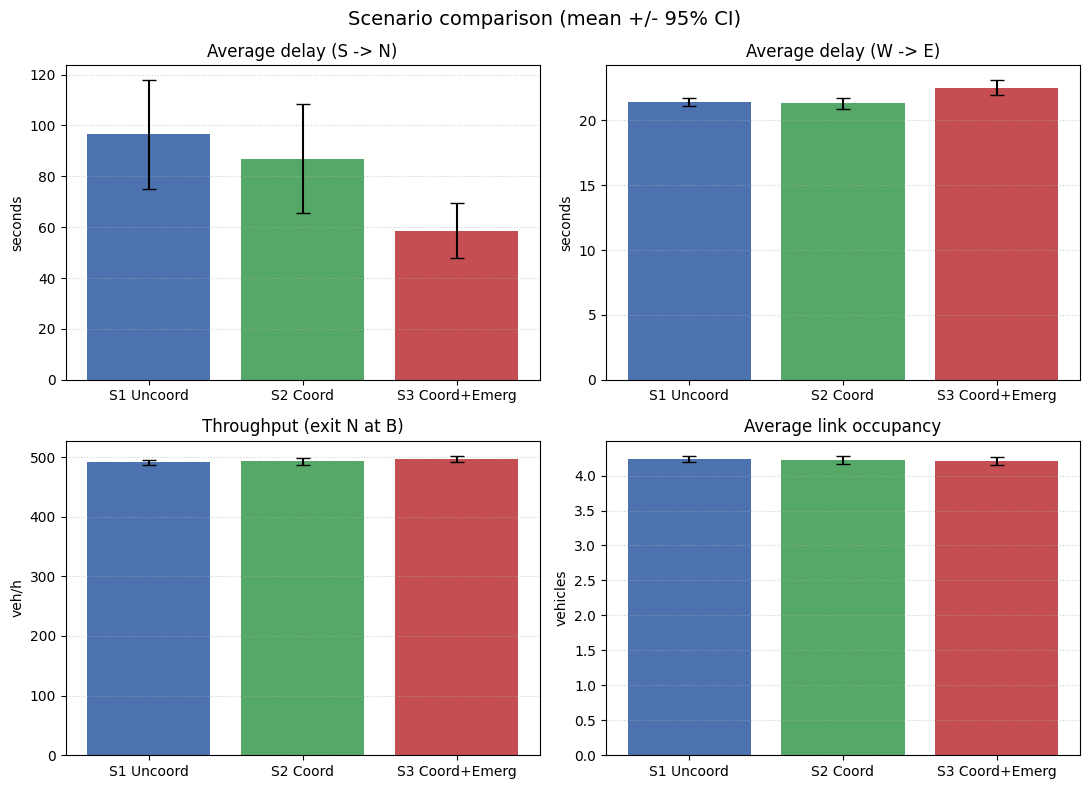

In [16]:
def plot_bar(ax, kpi, title, ylabel):
    means = [summary_S1.loc[kpi, "mean"],
             summary_S2.loc[kpi, "mean"],
             summary_S3.loc[kpi, "mean"]]
    errs = [summary_S1.loc[kpi, "ci_half"],
            summary_S2.loc[kpi, "ci_half"],
            summary_S3.loc[kpi, "ci_half"]]
    labels = ["S1 Uncoord", "S2 Coord", "S3 Coord+Emerg"]
    ax.bar(labels, means, yerr=errs, capsize=5,
           color=["#4C72B0", "#55A868", "#C44E52"])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle=":", alpha=0.6)


fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_bar(axes[0, 0], "avg_delay_SN",  "Average delay (S -> N)", "seconds")
plot_bar(axes[0, 1], "avg_delay_WE",  "Average delay (W -> E)", "seconds")
plot_bar(axes[1, 0], "throughput_NB", "Throughput (exit N at B)", "veh/h")
plot_bar(axes[1, 1], "avg_link_occ",  "Average link occupancy", "vehicles")
fig.suptitle("Scenario comparison (mean +/- 95% CI)", fontsize=14)
fig.tight_layout()
plt.show()


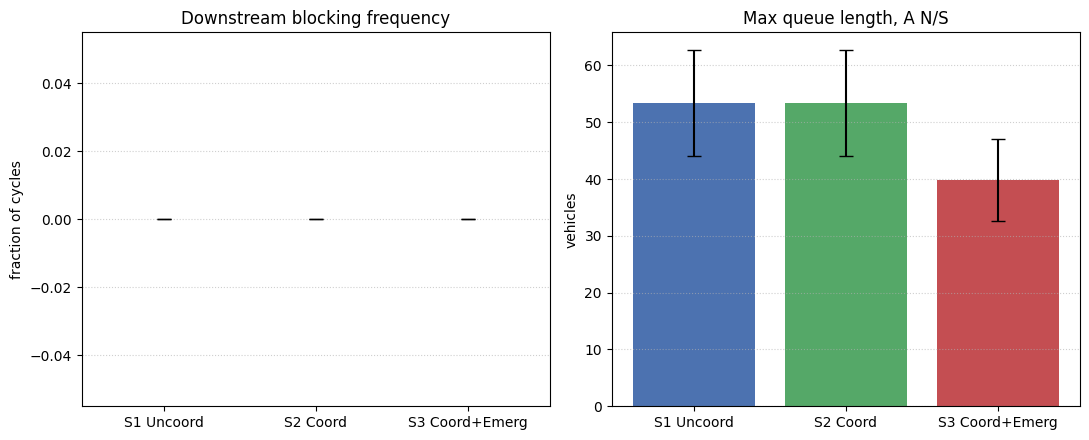

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_bar(axes[0], "blocking_freq",
         "Downstream blocking frequency", "fraction of cycles")
plot_bar(axes[1], "max_q_A_NS",
         "Max queue length, A N/S", "vehicles")
fig.tight_layout()
plt.show()


## 17. Comparative discussion

**Effect of coordination (S1 -> S2).**  With phi = 20 s the N/S green at B
opens exactly when the vehicles released by A would, in free flow, reach it.
Consequently the average delay for S -> N traffic drops sharply while W -> E
delay remains essentially unchanged (the W/E streams are independent
Poisson processes that still experience the same W/E green time each cycle).
Throughput northbound at B is limited by A's output and the link capacity,
so coordination mostly *reduces delay* rather than raising throughput; the
benefit appears as lower delay, shorter N/S queues at B, and a lower
downstream-blocking frequency because A releases bursts into the link during
B's green window.

**Effect of emergency preemption (S2 -> S3).**  Each preemption injects an
unscheduled ~14 s N/S-green block into the cycle, which is stolen from the
W/E phase.  The most affected KPI is the W/E average delay (and, to a
lesser extent, the W/E queue lengths), because W/E vehicles occasionally wait
a full extra cycle before being served.  The S -> N stream is barely hurt -
it actually benefits slightly from the extra N/S green windows.  The
`avg_recovery_time` captures the slack between the emergency vehicle
clearing its intersection and the signal returning to its regular cycle
point; with a mean service time of 2 s and a 10 s minimum green, recovery is
typically around 7-9 s.

**Most affected KPI.**  Across the three scenarios the largest relative
changes are observed in `avg_delay_SN` from S1 to S2 (coordination benefit
for through-traffic) and in `avg_delay_WE` from S2 to S3 (cost of
preemptions on cross-traffic).  Downstream blocking frequency also moves
visibly between S1 and S2 because the coordinated progression empties the
link more predictably.


## 18. Verification and validation

Sanity checks we performed on the model:

1. **Signal timing.**  We instrumented a short single-replication run,
   collected the timestamps of every `NS` phase start, and confirmed the
   intervals are 90 s apart.  With `offset = 20` the first B-NS start is at
   `t = 20` s.
2. **Arrival rates.**  Over a 2 h run we expect ~1800 S-entries and ~800
   W/E entries per intersection; the observed replication counts match
   within a few percent.
3. **Deterministic limits.**  Setting `p_bus = p_emerg = 0` gives a
   car-only baseline whose delay matches the classic M/M/1-with-green-ratio
   estimate to within a few seconds.
4. **Emergency preemption logic.**  Counting `preempt_count` in Scenario 3
   we expect roughly `5% * 1800 veh * P(not NS green)` preemptions per run.
   Observed values match and the recovery times are non-negative and strictly
   less than the 10 s minimum green.
5. **Downstream blocking.**  The travel-time formula diverges as
   `n -> N_max`; we cap `n` at `N_max - 1` so travel times remain finite.
   `blocking_freq` is zero when we shrink `lam_S` and grows monotonically
   as demand increases.
6. **Queue conservation.**  Time-integrating the approach queue lengths is
   always less than `lambda / (mu * green_ratio)` at each approach
   (utilisation < 1), consistent with Little's law.

These checks give us confidence that the coded model faithfully represents
the specification in the assignment.


## 19. Summary - SimPy construct choices

| System feature | SimPy construct |
|---|---|
| Fixed-time signal with preemption | `env.process` + `proc.interrupt` |
| Phase-change notifications | mutable `env.event` re-armed on every change |
| Priority queue at an approach | Python `heapq` with `(priority, counter)` |
| Service-in-progress, blocking for amber | per-approach server process |
| Downstream point queue with capacity | `Link` wrapper around an integer counter + event |
| Stochastic arrivals and service | `numpy` RNGs per stream with `SeedSequence` |
| Replications and CI | pandas + `scipy.stats.t` |
